In [11]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

import oreonspy as op

plt.rcParams['figure.figsize'] = [6, 6]

## Input pulse preparation

Input field shape: (21,), min=0.000e+00, max=9.139e-01


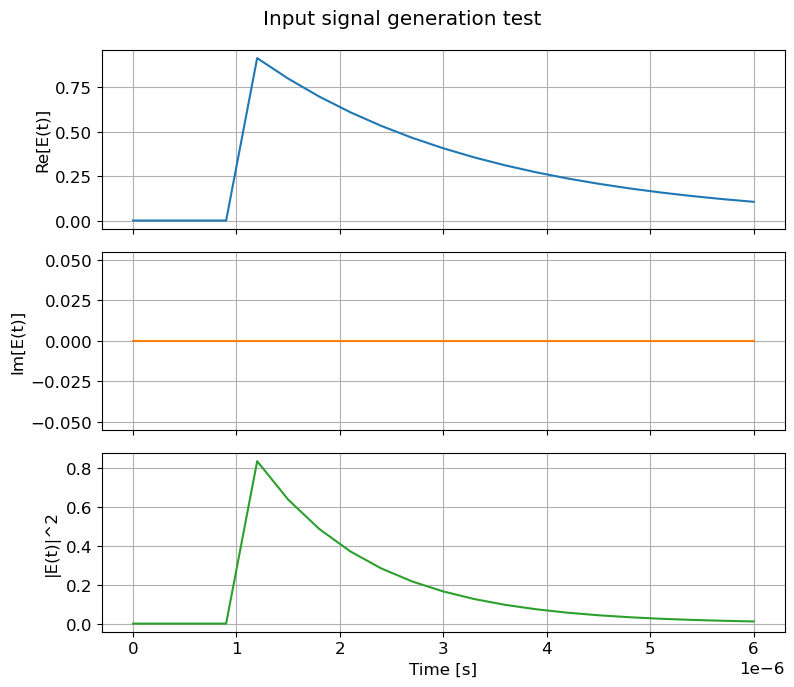

In [12]:
# === Test parameters for exponential pulse generation ===
# These global parameters are used later when generating input pulses for the cavity simulations.
E0 = 1.0                    # Pulse amplitude (normalized to 1)
gamma = -4.5e5              # Decay rate [rad/s]; negative for decaying envelope
pre_interval = 1e-6         # Duration of silent region before pulse onset [s] (1 µs)
pre_value = 0.0             # Field value during pre-pulse silence (zero suppresses kickstart transients)
t_start = 0.0               # Simulation window start time [s]
t_stop = 6e-6               # Simulation window end time [s] (6 µs total)
num_points = 20             # Minimum sample points for plotting (test only)
fs_desired = num_points / (t_stop - t_start)  # Coarse test sampling frequency (~3.3 kHz)

def make_exponential_input_pulse(
    E0=1.0,
    gamma=-4.5e5,
    pre_interval=1e-6,
    pre_value=0.0,
    t_start=0.0,
    t_stop=6e-6,
    fs=None,
):
    """Generate an exponential input pulse on a uniformly sampled time grid.
    
    The pulse has two regions:
    - [t_start, pre_interval): constant pre_value (silent region to avoid transients)
    - [pre_interval, t_stop]: exponential decay E(t) = E0 * exp(gamma * (t - pre_interval))

    Parameters
    ----------
    E0 : float
        Peak pulse amplitude.
    gamma : float
        Decay rate [rad/s]. Negative = decay, positive = growth.
    pre_interval : float
        Duration of silent region before pulse onset [s].
    pre_value : float
        Constant field value during pre-pulse silence.
    t_start, t_stop : float
        Simulation time window [s].
    fs : float or None
        Sampling frequency [Hz]. When provided it sets:
        ``num_points = round((t_stop - t_start) * fs) + 1``.
    """
    num_points = round((t_stop - t_start) * fs) + 1
    assert num_points > 1, f"num_points must be greater than 1 to create a valid time grid. Minimum fs is {(2)/(t_stop - t_start):.2f} Hz for the given time range."

    t_plot = np.linspace(t_start, t_stop, num_points)

    # Exponential pulse starts after pre_interval
    E_pulse = E0 * np.exp(gamma * (t_plot - pre_interval))

    # Before pre_interval: constant; after: pulse
    E_in_simple = np.where(t_plot < pre_interval, pre_value, E_pulse)

    return t_plot, E_in_simple


# === Generate and visualize test pulse ===
t_plot, E_in_simple = make_exponential_input_pulse(
    E0=E0,
    gamma=gamma,
    pre_interval=pre_interval,
    pre_value=pre_value,
    fs=fs_desired * 1  # Coarse sampling for initial validation
)
print(f"Input field shape: {E_in_simple.shape}, min={E_in_simple.min():.3e}, max={E_in_simple.max():.3e}")

# === Plot: real, imaginary, and power components of the test pulse ===
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
fig.suptitle("Input signal generation test")

axs[0].plot(t_plot, np.real(E_in_simple))
axs[0].set_ylabel("Re[E(t)]")
axs[0].grid(True)

axs[1].plot(t_plot, np.imag(E_in_simple), color="C1")
axs[1].set_ylabel("Im[E(t)]")
axs[1].grid(True)

axs[2].plot(t_plot, np.abs(E_in_simple)**2, color="C2")
axs[2].set_ylabel("|E(t)|^2")
axs[2].set_xlabel("Time [s]")
axs[2].grid(True)

plt.tight_layout()


In [13]:
# === Simulator harness: initialize cavity, generate input, run loop ===
def simulation_check(fs_desired, lambd, cavity_params, E_in_params):
    """Run round-trip simulator for a single cavity configuration and input pulse.
    
    Parameters
    ----------
    fs_desired : float
        Requested sampling frequency [Hz] (may be quantized by simulator).
    lambd : float
        Resonant wavelength [m].
    cavity_params : dict
        Cavity parameters: 't_a', 'r_a', 'r_b', 'cavity_length'.
    E_in_params : dict
        Input pulse parameters: 'E0', 'gamma', 'pre_interval', 'pre_value', 't_start', 't_stop'.
    
    Returns
    -------
    ein : np.ndarray
        Input electric field [complex, normalized].
    rt_sim_res : np.ndarray
        Intracavity electric field from sim_step loop [complex].
    tdata : np.ndarray
        Time grid [s] at the actual sampling frequency.
    fs_real : float
        Actual sampling frequency used by simulator [Hz].
    """
    
    # === Initialize cavity with Fabry-Perot mirror parameters ===
    cavity = op.Cavity(
        t_a=cavity_params['t_a'],
        r_a=cavity_params['r_a'],
        r_b=cavity_params['r_b'],
        cavity_length=cavity_params['cavity_length'],
        debug=True
    )
    
    # === Configure simulator ===
    # Note: op.Cavity.simulation expects wavelength (not wave number).
    # Initial field is set to pre_value to avoid transient kickstart.
    cavity.simulation(
        lambd,
        fs_desired,
        initial_input_electric_field=E_in_params['pre_value'],
        backend="numba"  # Use Numba-compiled backend for speed
    )
    
    # === Extract actual sampling frequency (may differ from requested) ===
    fs_real = cavity.sim_params.sampling_frequency
    
    # === Generate input pulse at the actual sampling frequency ===
    tdata, ein = make_exponential_input_pulse(
        E0=E_in_params['E0'],
        gamma=E_in_params['gamma'],
        pre_interval=E_in_params['pre_interval'],
        pre_value=E_in_params['pre_value'],
        t_start=E_in_params['t_start'],
        t_stop=E_in_params['t_stop'],
        fs=fs_real  # Use actual fs to ensure time grid alignment
    )

    # === Print simulator parameter summary ===
    cavity.print_sim_params()

    # === Run time-stepping loop ===
    # Initialize output array to store intracavity field at each time step.
    rt_sim_res = np.zeros(len(tdata), dtype=np.complex_)
    
    # Step through simulation:
    # - ein[idx]: input field at this time step
    # - 0.: input mirror displacement (zero for static cavity)
    # - 0.: output mirror displacement (zero for static cavity)
    for idx, t in enumerate(tdata):
        rt_sim_res[idx], _ = cavity.sim_step(ein[idx], 0., 0.)

    return ein, rt_sim_res, tdata, fs_real


# === Plotting harness: visualize input, output, and transmission ===
def simulation_check_plot(
    ein, rt_sim_res, tdata,
    full_plot=False, t_b=1.0, ratio_power_floor=1e-10, plot_amplitude=False
):
    """Plot input, intracavity field, and amplitude transmission from simulation.
    
    Parameters
    ----------
    ein : np.ndarray
        Input electric field [complex].
    rt_sim_res : np.ndarray
        Intracavity electric field [complex].
    tdata : np.ndarray
        Time grid [s].
    full_plot : bool, optional
        If True, create 3-panel layout (power, phase, input).
        If False, create 1-panel layout (power only, with inset transmission).
    t_b : float, optional
        Output-coupler amplitude transmissivity (scales intracavity→output field).
    ratio_power_floor : float, optional
        Noise threshold [power units]. Avoid computing T(t) where |E_in|^2 < threshold.
    plot_amplitude : bool, optional
        If True, plot amplitude |E|. If False, plot power |E|^2.
    """
    
    # === Select plot variable (amplitude vs power) ===
    if not plot_amplitude:
        ein_loc = np.abs(ein)**2
        rt_sim_res_loc = np.abs(rt_sim_res * t_b)**2
        label_loc = "power"
    else:
        ein_loc = ein
        rt_sim_res_loc = rt_sim_res * t_b
        label_loc = "amplitude"
    
    # === Create figure and axes ===
    # Single pane (power + inset transmission) or full 3-panel layout.
    fig, axs = plt.subplots(3 if full_plot else 1, 1, figsize=(10, 7), sharex=full_plot)
    plt.subplots_adjust(wspace=8.)

    # Main power/amplitude plot
    power_ax = axs[0] if full_plot else axs
    power_ax.grid(visible=True)
    
    # === Plot output field ===
    power_ax.plot(tdata, rt_sim_res_loc, label="output " + label_loc, color='C1', ls="--", marker="")
    
    # === Plot input field (only if not full multi-panel layout) ===
    if full_plot == False:
        power_ax.plot(tdata, ein_loc, label="input " + label_loc, color='C0', ls="--", marker="")
    
    power_ax.set_ylabel(label_loc)
    power_ax.set_xlabel("time")
    power_ax.legend()

    # === Optional: phase plot (only in full_plot mode) ===
    if full_plot:
        phase_ax = axs[1]
        phase_ax.grid(visible=True)
        # Unwrap phase in degrees then convert back to radians (handles 2π wraps).
        phase_ax.plot(tdata, (np.unwrap(np.angle(rt_sim_res, deg=True)*2))/2, label="RT sim. phase")
        phase_ax.set_xlabel("time")
        phase_ax.set_ylabel("phase")
        phase_ax.legend()

    # === Optional: input-only plot (only in full_plot mode) ===
    if full_plot:
        input_ax = axs[2]
        input_ax.grid(visible=True)
        input_ax.plot(tdata, ein_loc, label="input " + label_loc, color='C0', ls="--", marker="")
        input_ax.set_xlabel("time")
        input_ax.set_ylabel("|E_in|^2")

    # === Compute transmission ratio T(t) = E_out / E_in ===
    E_out = rt_sim_res * t_b  # Output field (drop port amplitude)
    ratio = np.full_like(E_out, np.nan + 0j)
    # Only compute ratio where input power exceeds noise floor (avoid dividing by noise).
    np.divide(E_out, ein, out=ratio, where=np.abs(ein)**2 > ratio_power_floor)

    # === Create inset axes for transmission plot (below main power plot) ===
    ratio_ax = power_ax.inset_axes([0.0, -0.55, 1.0, 0.4])
    ratio_ax.sharex(power_ax)
    ratio_ax.grid(visible=True)
    ratio_ax.plot(tdata, np.abs(ratio), color="C3", label=r"$|E_{out}/E_{in}|$")
    ratio_ax.set_ylabel("ratio")
    ratio_ax.set_xlabel("time")
    ratio_ax.legend(loc="best")

    fig.tight_layout()


## Converting decay rates to mirror reflectivities and trasmissivities

The `oreonspy` simulator models a two-mirror Fabry-Pérot cavity. The microresonator from Xue et al. is a ring cavity described by coupled-mode theory (CMT) with three decay rates:

| Symbol | Meaning |
|--------|---------|
| $\kappa_1$ | Power coupling rate into port 1 (input coupler) |
| $\kappa_2$ | Power coupling rate into port 2 (drop port) |
| $\kappa_i$ | Intrinsic loss rate (absorption + scattering) |
| $\kappa = \kappa_1 + \kappa_2 + \kappa_i$ | Total power decay rate |

The round-trip time of the equivalent FP is

$$T_\mathrm{rt} = \frac{2L_\mathrm{equiv}}{c}$$

where $L_\mathrm{equiv} = \pi d$ is the ring circumference.

### Amplitude transmissivities $t_{a,b}$

Each port coupling $\kappa_{1,2}$ removes a fraction of the stored energy per unit time. Over one round trip the power fraction coupled out through mirror $a$ (port 1) is $1 - e^{-2\kappa_1 T_\mathrm{rt}}$, so the amplitude transmissivity is

$$t_a = \sqrt{1 - e^{-2\kappa_1 T_\mathrm{rt}}}, \qquad t_b = \sqrt{1 - e^{-2\kappa_2 T_\mathrm{rt}}}$$

### Amplitude reflectivities $r_{a,b}$

The intrinsic loss $\kappa_i$ is split equally between the two mirrors ($\kappa_i/2$ each). The round-trip amplitude decay factor at mirror $a$ combines input-coupling loss and half the intrinsic loss:

$$r_a = e^{-(\kappa_1 + \kappa_i/2)\, T_\mathrm{rt}}, \qquad r_b = e^{-(\kappa_2 + \kappa_i/2)\, T_\mathrm{rt}}$$

Note that $t_a^2 + r_a^2 < 1$ (and similarly for $b$) precisely because the intrinsic loss makes each mirror absorptive. The photon lifetime of the equivalent FP is recovered as

$$\tau = \frac{T_\mathrm{rt}}{-\ln(r_a r_b)} \approx \frac{1}{\kappa_1 + \kappa_2 + \kappa_i} = \frac{1}{\kappa}$$

### Parameters from Nature add-drop cavity ([s41467-026-70123-w](https://doi.org/10.1038/s41467-026-70123-w))

Use the reported values:
$\lambda = 1560\,nm$,
$\kappa_i$ = 0,4 MHz,
$\kappa_1$ = 0,3 MHz,
$\kappa_2$ = 0,3 MHz


In [14]:
# Reported values
c = const.c
lam = 1560e-9             # m

omega0 = 2.0 * np.pi * c / lam

# Coupling rates from transmittance model
kappa_1 = 0.3e6
kappa_2 = 0.3e6
kappa_i = 0.4e6

kappa = kappa_1 + kappa_2 + kappa_i

# Consistency check
T_drop_check = 4.0 * kappa_1 * kappa_2 / kappa**2
T_through_check = (1.0 - 2.0 * kappa_1 / kappa) ** 2

#print(f"kappa = {kappa:.6e} s^-1 = {kappa/1e6:.3f} MHz")
print(f"omega0 = {omega0:.6e} rad/s")
#print(f"Q_loaded = {Q_loaded:.3e}")
#print(f"Delta_omega = {Delta_omega:.6e} rad/s")
#print(f"kappa_from_linewidth = {kappa_from_linewidth:.6e} s^-1 = {kappa_from_linewidth/1e6:.3f} MHz")
print()
print(f"kappa_1 = {kappa_1/1e6:.3f} MHz")
print(f"kappa_2 = {kappa_2/1e6:.3f} MHz")
print(f"kappa_i = {kappa_i/1e6:.3f} MHz")
print()
print(f"T_drop_check = {T_drop_check:.3f}")
print(f"T_through_check = {T_through_check:.3f}")

omega0 = 1.207469e+15 rad/s

kappa_1 = 0.300 MHz
kappa_2 = 0.300 MHz
kappa_i = 0.400 MHz

T_drop_check = 0.360
T_through_check = 0.160


In [15]:
# === Equivalent Fabry-Perot cavity parameters from CMT decay rates ===
# Map the reported CMT decay rates (kappa_1, kappa_2, kappa_i) onto
# the oreonspy Cavity model via amplitude transmissivity and reflectivity.

# Wavelength and geometry
lambd = lam  # Resonant wavelength [m] from the Nature paper
diameter = 1.0e-3  # Ring cavity diameter [m]
L_equiv = np.pi * diameter  # Equivalent cavity length (ring circumference) [m]

# Round-trip time through the equivalent FP
T_rt = 2.0 * L_equiv / const.c  # [s]

# === Amplitude transmissivities: derived from power coupling rates ===
# Each coupling rate kappa_j removes a fraction of energy per round trip.
# For power fraction F_coupled = 1 - exp(-2*kappa*T_rt), the amplitude
# transmissivity is t = sqrt(F_coupled), accounting for the sqrt of power conversion.
t_a = np.sqrt(1.0 - np.exp(-2.0 * kappa_1 * T_rt))  # Input-coupler transmissivity
t_b = np.sqrt(1.0 - np.exp(-2.0 * kappa_2 * T_rt))  # Output-coupler transmissivity

# === Amplitude reflectivities: direct amplitude decay with intrinsic loss ===
# Intrinsic loss kappa_i is split equally between both mirrors (kappa_i/2 each).
# At each mirror, round-trip amplitude decay includes both port coupling and loss.
kappa_i_half = 0.5 * kappa_i
r_a = np.exp(-(kappa_1 + kappa_i_half) * T_rt)  # Input-coupler reflectivity
r_b = np.exp(-(kappa_2 + kappa_i_half) * T_rt)  # Output-coupler reflectivity

# === Power conservation checks ===
# For absorptive mirrors (with intrinsic loss), we expect t^2 + r^2 < 1.
# The missing power is absorbed per round trip: loss_fraction = 1 - (t^2 + r^2)
print("Round-trip time: {:.3e} s\n".format(T_rt))

print("=== Mirror A (input coupler) ===")
power_conservation_check_a = t_a**2 + r_a**2
loss_a = 1.0 - power_conservation_check_a
print(f"  t_a^2 + r_a^2 = {power_conservation_check_a:.6f} (power loss fraction: {loss_a:.3e})")
assert 0.0 < power_conservation_check_a < 1.0, f"Unphysical t_a={t_a:.3e}. Check kappa_1 and L_equiv."

print("=== Mirror B (output coupler) ===")
power_conservation_check_b = t_b**2 + r_b**2
loss_b = 1.0 - power_conservation_check_b
print(f"  t_b^2 + r_b^2 = {power_conservation_check_b:.6f} (power loss fraction: {loss_b:.3e})")
assert 0.0 < power_conservation_check_b < 1.0, f"Unphysical t_b={t_b:.3e}. Check kappa_2 and L_equiv."

# === Cavity length tuning ===
# Adjust L to set free spectral range (FSR) properties. Default: FSR = 0
# (i.e., one cavity length = integer number of wavelengths).
L = L_equiv
L = int(L / lambd) * lambd  # Tune FSR to zero (alternative: subtract (lambda/2) for FSR offset)

# === Verify lifetime consistency ===
# Photon lifetime from reflectivity product: tau = T_rt / (-ln(r_a * r_b))
# Should approximately equal 1/kappa for the coupled system.
tau_check = (2.0 * L / const.c) / (-np.log(r_a * r_b))

# === Print summary of FP mapping ===
print("\n=== Geometry and parameters ===")
print(f"  Diameter: {diameter*1e3:.3f} mm")
print(f"  Cavity length L: {L:.6e} m ({L*1e3:.6f} mm)")
print(f"  Wavelength: {lambd:.3e} m")
print(f"\n  Reflectivities: r_a = {r_a:.9f}, r_b = {r_b:.9f}")
print(f"  Transmissivities: t_a = {t_a:.9f}, t_b = {t_b:.9f}")
print(f"\n  Photon lifetime (FP): {tau_check*1e6:.6f} µs")
print(f"  Total decay rate (CMT): kappa = {kappa/1e6:.3f} MHz → tau = {1/(kappa)*1e6:.6f} µs")


Round-trip time: 2.096e-11 s

=== Mirror A (input coupler) ===
  t_a^2 + r_a^2 = 0.999992 (power loss fraction: 8.383e-06)
=== Mirror B (output coupler) ===
  t_b^2 + r_b^2 = 0.999992 (power loss fraction: 8.383e-06)

=== Geometry and parameters ===
  Diameter: 1.000 mm
  Cavity length L: 3.140280e-03 m (3.140280 mm)
  Wavelength: 1.560e-06 m

  Reflectivities: r_a = 0.999989521, r_b = 0.999989521
  Transmissivities: t_a = 0.003546123, t_b = 0.003546123

  Photon lifetime (FP): 0.999582 µs
  Total decay rate (CMT): kappa = 1.000 MHz → tau = 1.000000 µs


## Minimal working example

In [16]:
theoretical_cavity = op.Cavity(t_a=t_a, r_a=r_a, r_b=r_b, cavity_length=L)
print(theoretical_cavity)

In [17]:

# Select a single decay rate for this isolated test.
# Uncomment other values to test the below-threshold, threshold-like, or above-threshold regimes.
gamma = -0.4e6  # Below-threshold: omega_im = 0.4 MHz
#gamma = -1.0e6  # Threshold-like: omega_im = 1.0 MHz
#gamma = -1.2e6  # Above-threshold: omega_im = 1.2 MHz

# Keep this single-run test independent from later sweep cells.
t_start_theoretical = 0.0
t_stop_theoretical = 6e-6
# High sampling frequency (33.3 MHz).
fs_here = 3333333.0 * 10
print(f"Testing with fs = {fs_here/1e6:.2f} MHz.")

# Assemble cavity parameters from the CMT-to-FP mapping computed earlier.
cavity_params = {
    't_a': t_a,         # input-coupler amplitude transmissivity
    'r_a': r_a,         # input-coupler amplitude reflectivity
    'r_b': r_b,         # output-coupler amplitude reflectivity
    'cavity_length': L,  # equivalent FP cavity length
}

# Assemble input pulse parameters for this single run.
E_in_params = {
    'E0': E0,                          # pulse amplitude
    'gamma': gamma,                    # decay rate (negative = decaying)
    'pre_interval': pre_interval,      # time before pulse onset
    'pre_value': 0,                    # field value during pre-pulse silence
    't_start': t_start_theoretical,
    't_stop': t_stop_theoretical,      # 6 µs total window
}

# Run the simulator: returns input field, intracavity field, time grid, and actual fs used.
ein, rt_sim_res, tdata, fs_real = simulation_check(
    fs_here,
    lambd,
    cavity_params=cavity_params,
    E_in_params=E_in_params,
)  # Static cavity (no moving mirrors)


Testing with fs = 33.33 MHz.
wave_number: 4027682.889217683
k2j: -8055365.778435366j
requested_sampling_frequency: 33333330.0
initial_input_electric_field: 0
sampling_frequency: 33333377.14147541
num_roundtrips: 1432
Theta: 2.9999960572723946e-08
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.9999985857555963


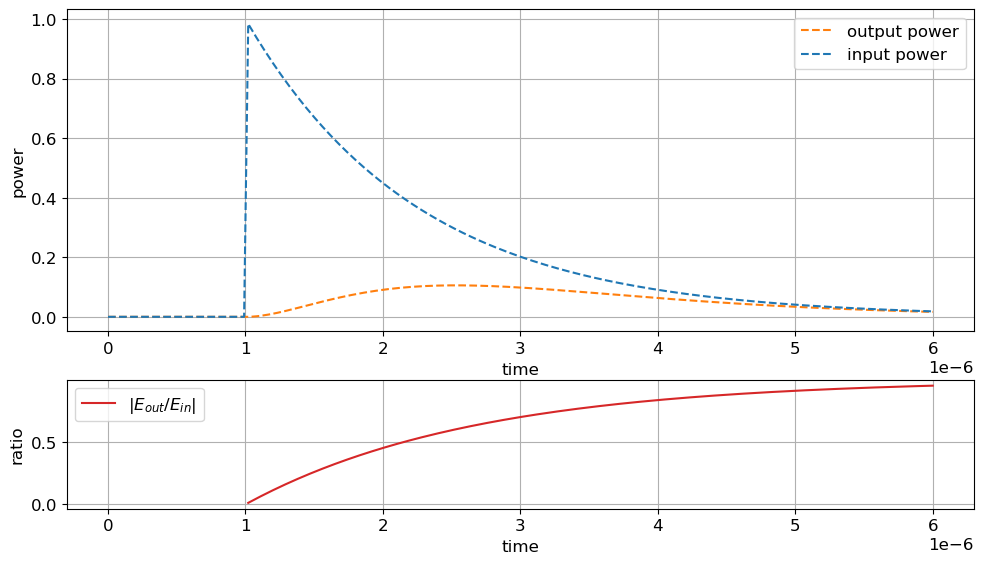

In [18]:
simulation_check_plot(ein, rt_sim_res, tdata, full_plot=False, t_b=t_b, ratio_power_floor=1e-6, plot_amplitude=False)

## Reproduce amplitude decay - pane **a** in Figure 2

"**a** Illustration of input (blue) and output (red) pulses at $\Delta = 0$ under various excitation scenarios. The total loss rate of the system is set to be $\kappa = 1$ MHz. The below-threshold scenario is demonstrated at $\omega_\mathrm{im} = 0.4$ MHz, the threshold-like transition is demonstrated at $\omega_\mathrm{im} = 1$ MHz, and the above-threshold scenario is demonstrated at $\omega_\mathrm{im} = 1.2$ MHz."

wave_number: 4027682.889217683
k2j: -8055365.778435366j
requested_sampling_frequency: 33333333.33333333
initial_input_electric_field: 0.0
sampling_frequency: 33333377.14147541
num_roundtrips: 1432
Theta: 2.9999960572723946e-08
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.9999986857557376
wave_number: 4027682.889217683
k2j: -8055365.778435366j
requested_sampling_frequency: 33333333.33333333
initial_input_electric_field: 0.0
sampling_frequency: 33333377.14147541
num_roundtrips: 1432
Theta: 2.9999960572723946e-08
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.9999986857557376
wave_number: 4027682.889217683
k2j: -8055365.778435366j
requested_sampling_frequency: 33333333.33333333
initial_input_electric_field: 0.0
sampling_frequency: 33333377.14147541
num_roundtrips: 1432
Theta: 2.9999960572723946e-08
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.999998685755737

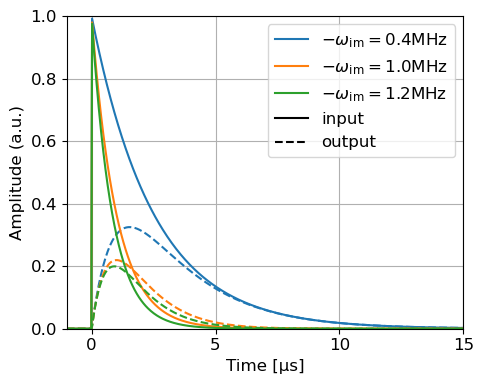

In [19]:

# Three values of the imaginary-frequency shift omega_im (negative = decay, per paper convention): E_in(t) ~ exp(gamma * t).
omega_im = [-0.4e6, -1.0e6, -1.2e6]
colors = ["C0", "C1", "C2"]

fig, ax = plt.subplots(figsize=(5, 4))
fontsize = 12
plt.rcParams.update({'font.size': fontsize})

for g, color in zip(omega_im, colors):
    E_in_params_i = {
        "E0": E0,
        "gamma": g,
        "pre_interval": pre_interval,    # 1 µs of silence before the pulse starts
        "pre_value": pre_value,          # field amplitude during the silent interval
        "t_start": 0,
        "t_stop": 16e-6,                 # simulate 16 µs total (15 µs after pulse onset)
    }

    # Run the round-trip simulator at 10× the base fs to keep numerical error small.
    ein_g, rt_sim_res_g, tdata_g, fs_real_g = simulation_check(
        fs_desired*10,
        lambd,
        cavity_params=cavity_params,
        E_in_params=E_in_params_i,
    )

    # t_b scales the intracavity field to the output port amplitude (drop-port transmissivity).
    E_out_g = rt_sim_res_g * t_b

    # Shift time axis so t=0 coincides with pulse onset (pre_interval = 1 µs).
    ax.plot(
        tdata_g * 1e6 - 1.0,
        np.abs(ein_g),          # input amplitude envelope
        color=color,
        ls="-",
        label=fr"$-\omega_\mathrm{{im}}={-g/1e6}$MHz",
    )
    ax.plot(
        tdata_g * 1e6 - 1.0,
        np.abs(E_out_g),        # output amplitude envelope (dashed, same color)
        color=color,
        ls="--",
    )

ax.set_xlabel("Time [µs]")
ax.set_ylabel("Amplitude (a.u.)")
ax.set_xticks(np.arange(0, 16, 5))
ax.set_xlim(-1, 15)
ax.set_ylim(0, 1)
ax.grid(True)
# Dummy lines for the input/output legend entries (color-neutral).
ax.plot([], [], color="k", ls="-", label="input")
ax.plot([], [], color="k", ls="--", label="output")
ax.legend(ncol=1, fontsize=fontsize)
plt.tight_layout()


## Reproduce virtual gain - pane **b** in Figure 2

"**b** Simulated amplitude transmission TðtÞ plotted as a function of time for different levels of virtual gain. For moderate values of virtual gain, the transmission coefﬁcient reaches a quasi-steady state, with larger levels for larger gain. When the virtual gain reaches the threshold-like transition, TðtÞ exhibits
linear growth, and for larger gain values, it exponentially grows, indicating the breakdown of the quasi-steady state and the onset of lasing-like effects."

wave_number: 4027682.889217683
k2j: -8055365.778435366j
requested_sampling_frequency: 3333166.6666666665
initial_input_electric_field: 0.0
sampling_frequency: 3333104.9554216038
num_roundtrips: 14321
Theta: 3.0002055542037685e-07
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.9999814857007662
wave_number: 4027682.889217683
k2j: -8055365.778435366j
requested_sampling_frequency: 3333166.6666666665
initial_input_electric_field: 0.0
sampling_frequency: 3333104.9554216038
num_roundtrips: 14321
Theta: 3.0002055542037685e-07
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.9999814857007662
wave_number: 4027682.889217683
k2j: -8055365.778435366j
requested_sampling_frequency: 3333166.6666666665
initial_input_electric_field: 0.0
sampling_frequency: 3333104.9554216038
num_roundtrips: 14321
Theta: 3.0002055542037685e-07
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.999981

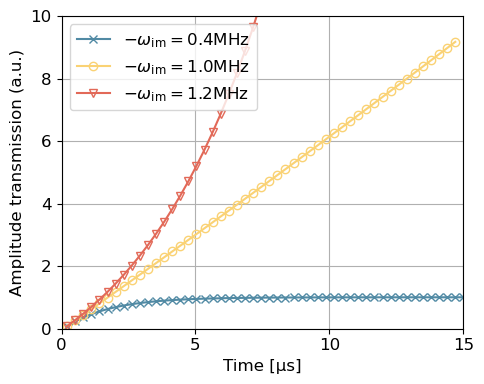

In [20]:
# Three values of the imaginary-frequency shift omega_im (negative = decay):
# this controls the exponential envelope of the input pulse.
omega_im = [-0.4e6, -1.0e6, -1.2e6]
makers = ["x", "o", "v"]
linecolors = ['#518aa4', '#fad274', '#e26958']

E0 = 1.0
pre_interval = 1e-6
pre_value = 0.0
t_start_theoretical_sweep = 0.0
t_stop_theoretical_sweep = 16e-6
# Compute sampling frequency to give roughly 20000 points over 6 µs (i.e., ~3.3 kHz spacing).
fs_desired = 0.001*(20000 - 1) / 6e-6

cavity_params = {
    't_a': t_a,
    'r_a': r_a,
    'r_b': r_b,
    'cavity_length': L,
}

fig, ax = plt.subplots(figsize=(5, 4))

fontsize = 12
plt.rcParams.update({'font.size': fontsize})

for g in omega_im:
    E_in_params_i = {
        'E0': E0,
        'gamma': g,
        'pre_interval': pre_interval,    # 1 µs silent region before pulse
        'pre_value': pre_value,          # initial field value (zero)
        't_start': t_start_theoretical_sweep,
        't_stop': t_stop_theoretical_sweep,  # 16 µs total simulation window
    }

    # Run the cavity simulation at requested fs_desired.
    ein_g, rt_sim_res_g, tdata_g, fs_real_g = simulation_check(
        fs_desired,
        lambd,
        cavity_params=cavity_params,
        E_in_params=E_in_params_i,
    )

    # Scale intracavity field to the output (drop-port) amplitude.
    E_out_g = rt_sim_res_g * t_b
    
    # Compute the amplitude transmission T(t) = |E_out / E_in|.
    # Only defined where |E_in|^2 > 1e-13 to avoid dividing by noise.
    ratio_g = np.full_like(E_out_g, np.nan + 0j)
    np.divide(E_out_g, ein_g, out=ratio_g, where=np.abs(ein_g) ** 2 > 1e-13)

    # Plot on time axis shifted to align t=0 with pulse onset (pre_interval = 1 µs).
    # Use index lookup to map the loop variable g to the correct color and marker.
    ax.plot(
        tdata_g * 1e6 - 1.0,
        np.abs(ratio_g),
        label=fr"$-\omega_\mathrm{{im}}={-g/1e6} \mathrm{{MHz}}$",
        color=linecolors[omega_im.index(g)],
        marker=makers[omega_im.index(g)],
        markerfacecolor="none"
    )

ax.set_xlim(0.0, 15.0)
ax.set_ylim(0.0, 10.0)
ax.set_xlabel("Time [µs]")
ax.set_ylabel(r"Amplitude transmission (a.u.)")
ax.grid(True)
ax.set_xticks(np.arange(0, 16, 5))
ax.legend(fontsize=fontsize)
plt.tight_layout()
